# TP7bis — Matrices de confusion : lecture, coût métier et choix du seuil

> **Objectif** : comprendre en détail ce que chaque cellule de la matrice de confusion
> signifie en termes **opérationnels**, pour chacun des 3 algorithmes du TP7.

| Algorithme | PR-AUC val (TP7) |
|---|---|
| Régression Logistique | 0.3569 |
| Random Forest | 0.7682 |
| XGBoost | **0.8174** |

### Rappel : la matrice 2×2

```
                   PRÉDICTION
                 Panne    OK
RÉALITÉ  Panne  [ TP ]  [ FN ]   ← ligne "vraie panne"
         OK     [ FP ]  [ TN ]   ← ligne "machine OK"
```

| Cellule | Nom | Scénario terrain |
|---|---|---|
| **TP** | Vrai Positif | Machine allait tomber en panne → modèle a prévenu ✅ |
| **FN** | Faux Négatif | Machine allait tomber en panne → modèle a dit OK ❌ |
| **FP** | Faux Positif | Machine était OK → modèle a déclenché une alerte ⚠️ |
| **TN** | Vrai Négatif | Machine était OK → modèle a dit OK ✅ |

## 1. Imports et données

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from sklearn.pipeline      import Pipeline
from sklearn.impute         import SimpleImputer
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_auc_score, f1_score, classification_report,
    precision_score, recall_score
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user",
    password="ThEP@ssW0rd",
    host="localhost",
    port=5432,
    database="indusense_db",
)
engine  = create_engine(url)
df      = pd.read_sql(
    "SELECT * FROM gold_machine_hourly_feature ORDER BY machine_id, window_start",
    engine
)
print(f"Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

TARGET   = "label_failure_next_24h"
LEAKAGE  = [
    "machine_id", "ingestion_batch_id", "window_start", "window_end", "split_set",
    "label_failure_next_6h", "label_failure_next_12h", "label_failure_next_48h", TARGET,
]
FEATS    = [c for c in df.columns if c not in LEAKAGE]

train_df = df[df["split_set"] == "train"]
val_df   = df[df["split_set"] == "validation"]

X_train, y_train = train_df[FEATS], train_df[TARGET]
X_val,   y_val   = val_df[FEATS],   val_df[TARGET]

neg_c = (y_train == 0).sum()
pos_c = (y_train == 1).sum()
SPW   = round(neg_c / pos_c, 2)

print(f"Train : {len(X_train):,} | Val : {len(X_val):,}")
print(f"Déséquilibre : {pos_c:,} positifs / {neg_c:,} négatifs → scale_pos_weight = {SPW}")

Dataset : 132,940 lignes × 79 colonnes
Train : 93,079 | Val : 19,917
Déséquilibre : 3,350 positifs / 89,729 négatifs → scale_pos_weight = 26.78


## 2. Entraînement des 3 modèles (mêmes conditions)

On utilise le même pipeline `SimpleImputer → Modèle` pour les 3 algorithmes
afin que les différences de résultat viennent **uniquement de l'algorithme**.

In [10]:
def make_pipe(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   model)
    ])

MODELS = {
    "Logistic Regression": make_pipe(
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    ),
    "Random Forest": make_pipe(
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    "XGBoost": make_pipe(
        XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=SPW, eval_metric="aucpr",
            random_state=RANDOM_STATE, verbosity=0
        )
    ),
}

RESULTS = {}
for name, pipe in MODELS.items():
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    y_pred  = pipe.predict(X_val)
    RESULTS[name] = {
        "pipe":    pipe,
        "y_proba": y_proba,
        "y_pred":  y_pred,
        "pr_auc":  round(average_precision_score(y_val, y_proba), 4),
    }
    print(f"{name:<22}  PR-AUC = {RESULTS[name]['pr_auc']:.4f}")

Logistic Regression     PR-AUC = 0.3105
Random Forest           PR-AUC = 0.8170
XGBoost                 PR-AUC = 0.8174


## 3. Matrices de confusion au seuil par défaut (0.5)

Le seuil 0.5 est le choix par défaut de scikit-learn et XGBoost.
On va voir comment les 3 modèles distribuent leurs erreurs différemment,
et ce que cela signifie pour l'équipe de maintenance.

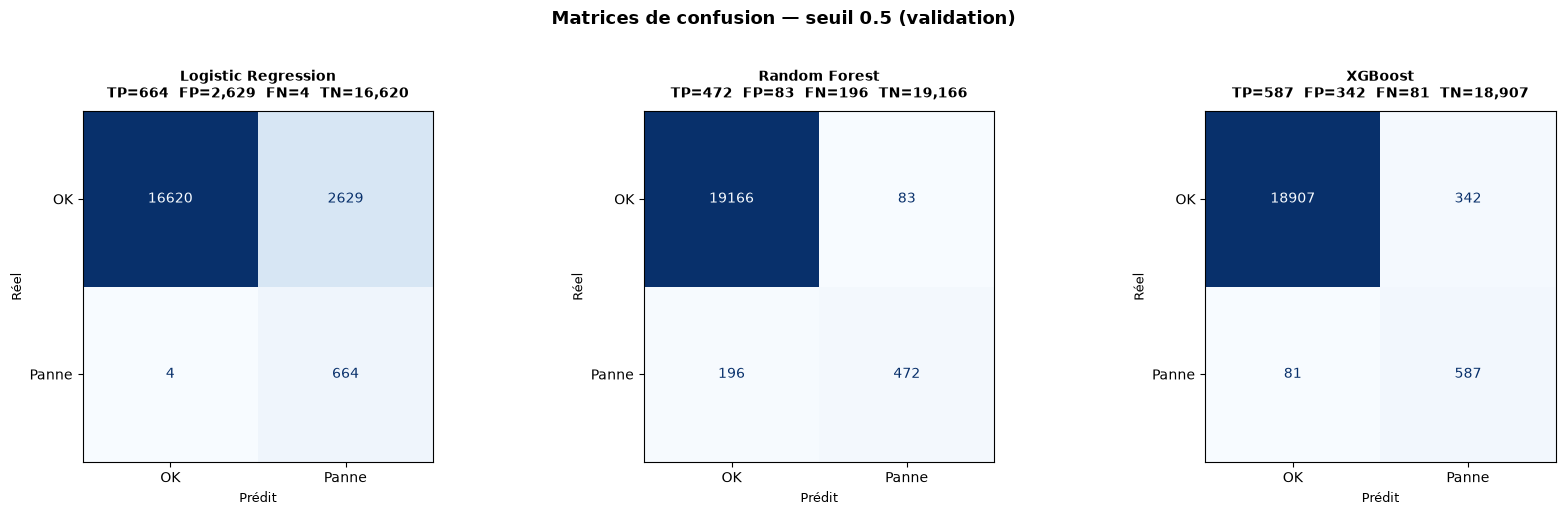

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, res) in zip(axes, RESULTS.items()):
    cm = confusion_matrix(y_val, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["OK", "Panne"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f"{name}\nTP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}",
        fontsize=10, fontweight="bold", pad=10
    )
    ax.set_xlabel("Prédit", fontsize=9)
    ax.set_ylabel("Réel", fontsize=9)

plt.suptitle("Matrices de confusion — seuil 0.5 (validation)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Lecture cellule par cellule et traduction métier

Pour chaque modèle, on détaille ce que chaque chiffre représente **sur le terrain**.

### Grille de lecture

| Cellule | Question terrain | Ce qui se passe si ce chiffre est élevé |
|---|---|---|
| **TP** | Combien de vraies pannes ai-je détectées ? | Parfait — pannes évitées, maintenance planifiée |
| **FN** | Combien de vraies pannes ai-je ratées ? | ❌ Arrêts non planifiés, coût de production, risque sécurité |
| **FP** | Combien de fois ai-je envoyé de fausses alertes ? | ⚠️ Déplacements inutiles, perte de confiance des techniciens |
| **TN** | Combien de fois ai-je correctement dit «tout va bien» ? | ✅ Silencieux, aucun coût |

In [12]:
# Tableau de synthèse cellule par cellule
rows = []
for name, res in RESULTS.items():
    cm   = confusion_matrix(y_val, res["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    total_pos = tp + fn   # toutes les vraies pannes
    total_neg = fp + tn   # toutes les machines OK
    rows.append({
        "Modèle"          : name,
        "TP — Pannes détectées" : f"{tp:,}  ({tp/total_pos*100:.1f}% des vraies pannes)",
        "FN — Pannes manquées"  : f"{fn:,}  ({fn/total_pos*100:.1f}% des vraies pannes)",
        "FP — Fausses alarmes"  : f"{fp:,}  ({fp/total_neg*100:.1f}% des cas OK)",
        "TN — OK corrects"      : f"{tn:,}  ({tn/total_neg*100:.1f}% des cas OK)",
        "Recall (↑ = mieux)"    : f"{tp/(tp+fn)*100:.1f}%",
        "Precision"             : f"{tp/(tp+fp)*100:.1f}%" if (tp+fp) > 0 else "—",
    })

summary = pd.DataFrame(rows).set_index("Modèle")
print(summary.to_string())
print(f"\nTotal vraies pannes dans val : {(y_val==1).sum():,}")
print(f"Total cas OK dans val        : {(y_val==0).sum():,}")

                              TP — Pannes détectées            FN — Pannes manquées       FP — Fausses alarmes            TN — OK corrects Recall (↑ = mieux) Precision
Modèle                                                                                                                                                                 
Logistic Regression  664  (99.4% des vraies pannes)     4  (0.6% des vraies pannes)  2,629  (13.7% des cas OK)  16,620  (86.3% des cas OK)              99.4%     20.2%
Random Forest        472  (70.7% des vraies pannes)  196  (29.3% des vraies pannes)      83  (0.4% des cas OK)  19,166  (99.6% des cas OK)              70.7%     85.0%
XGBoost              587  (87.9% des vraies pannes)   81  (12.1% des vraies pannes)     342  (1.8% des cas OK)  18,907  (98.2% des cas OK)              87.9%     63.2%

Total vraies pannes dans val : 668
Total cas OK dans val        : 19,249


## 5. Coût métier — quantifier l'asymétrie FN vs FP

En maintenance industrielle, les deux types d'erreurs n'ont pas le même coût.
On pose des hypothèses de coût unitaire pour visualiser l'impact financier.

### Hypothèses de coût unitaire

| Erreur | Coût unitaire estimé | Justification |
|---|---|---|
| **FN** (panne manquée) | 5 000 € | Arrêt non planifié : production perdue + intervention urgence + pièces en urgence |
| **FP** (fausse alarme) | 150 € | Déplacement technicien + 1–2h d'inspection inutile |

Ces valeurs sont à calibrer avec l'équipe métier. Le ratio FN/FP ≈ 33× justifie de **maximiser le Recall**.

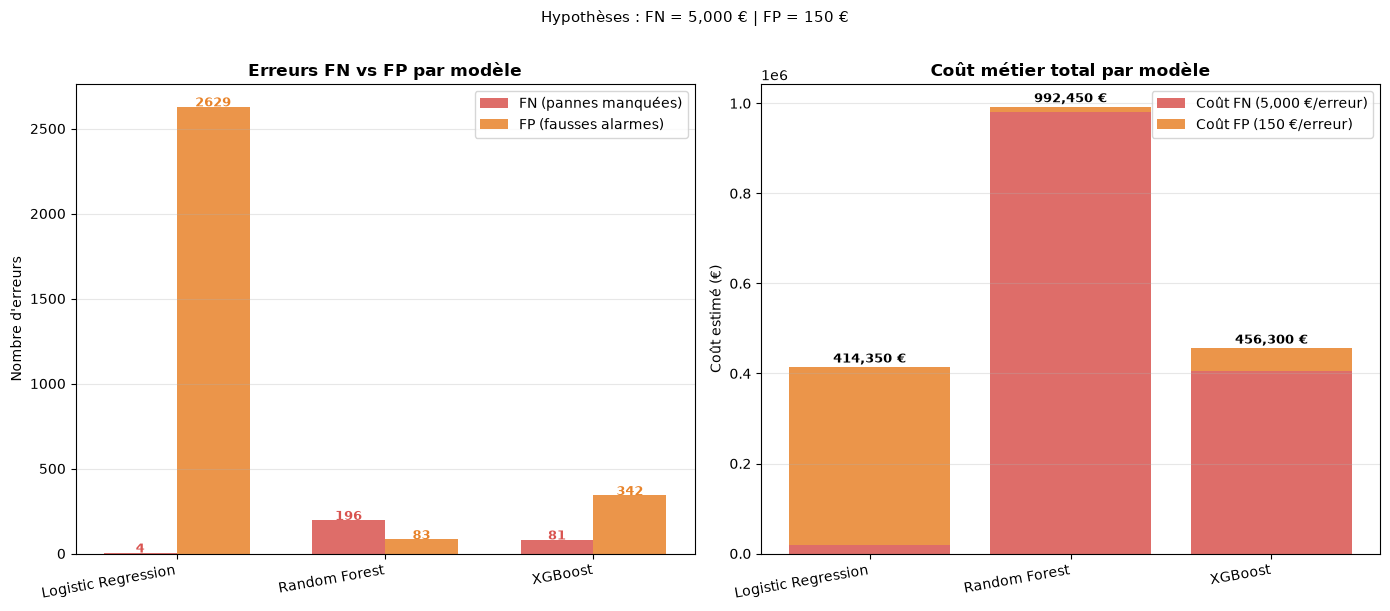

=== Coût estimé par modèle (seuil 0.5) ===
  Logistic Regression     Coût FN =     20,000 €  |  Coût FP =  394,350 €  |  Total =    414,350 €
  Random Forest           Coût FN =    980,000 €  |  Coût FP =   12,450 €  |  Total =    992,450 €
  XGBoost                 Coût FN =    405,000 €  |  Coût FP =   51,300 €  |  Total =    456,300 €


In [13]:
COST_FN = 5000   # € par panne manquée
COST_FP = 150    # € par fausse alarme

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

names_list = list(RESULTS.keys())
fn_vals, fp_vals, cost_fn_vals, cost_fp_vals, total_costs = [], [], [], [], []

for name, res in RESULTS.items():
    cm = confusion_matrix(y_val, res["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    fn_vals.append(fn)
    fp_vals.append(fp)
    cost_fn_vals.append(fn * COST_FN)
    cost_fp_vals.append(fp * COST_FP)
    total_costs.append(fn * COST_FN + fp * COST_FP)

# Graphe 1 : nombre d'erreurs FN et FP côte à côte
x = np.arange(len(names_list))
w = 0.35
bars_fn = axes[0].bar(x - w/2, fn_vals, w, label="FN (pannes manquées)", color="#D9534F", alpha=0.85)
bars_fp = axes[0].bar(x + w/2, fp_vals, w, label="FP (fausses alarmes)", color="#E8832A", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names_list, rotation=10, ha="right")
axes[0].set_ylabel("Nombre d'erreurs")
axes[0].set_title("Erreurs FN vs FP par modèle", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")
for bar in bars_fn: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(int(bar.get_height())), ha="center", fontsize=9, color="#D9534F", fontweight="bold")
for bar in bars_fp: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(int(bar.get_height())), ha="center", fontsize=9, color="#E8832A", fontweight="bold")

# Graphe 2 : coût total empilé
bars_cfn = axes[1].bar(x, cost_fn_vals, label=f"Coût FN ({COST_FN:,} €/erreur)", color="#D9534F", alpha=0.85)
bars_cfp = axes[1].bar(x, cost_fp_vals, bottom=cost_fn_vals, label=f"Coût FP ({COST_FP:,} €/erreur)", color="#E8832A", alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(names_list, rotation=10, ha="right")
axes[1].set_ylabel("Coût estimé (€)")
axes[1].set_title("Coût métier total par modèle", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")
for i, (tot, base) in enumerate(zip(total_costs, [0]*3)):
    axes[1].text(i, tot + max(total_costs)*0.01, f"{tot:,} €", ha="center", fontsize=9, fontweight="bold")

plt.suptitle(f"Hypothèses : FN = {COST_FN:,} € | FP = {COST_FP:,} €", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("=== Coût estimé par modèle (seuil 0.5) ===")
for name, cfn, cfp, tot in zip(names_list, cost_fn_vals, cost_fp_vals, total_costs):
    print(f"  {name:<22}  Coût FN = {cfn:>10,} €  |  Coût FP = {cfp:>8,} €  |  Total = {tot:>10,} €")

## 6. Comment le seuil de décision modifie la matrice de confusion

Le seuil est la valeur au-dessus de laquelle on déclenche une alerte.

```
P(panne) >= seuil  →  alerte émise  (prédit = 1)
P(panne) <  seuil  →  aucune alerte (prédit = 0)
```

**Baisser le seuil** :
- Plus d'alertes émises → plus de TP **et** plus de FP
- Moins de pannes manquées (↓ FN) mais plus de fausses alarmes (↑ FP)
- Recall ↑, Precision ↓

**Monter le seuil** :
- Moins d'alertes émises → moins de FP **et** moins de TP
- Plus de pannes manquées (↑ FN) mais moins de fausses alarmes (↓ FP)
- Recall ↓, Precision ↑

On cherche le seuil qui équilibre ces deux effets **selon la priorité métier**.

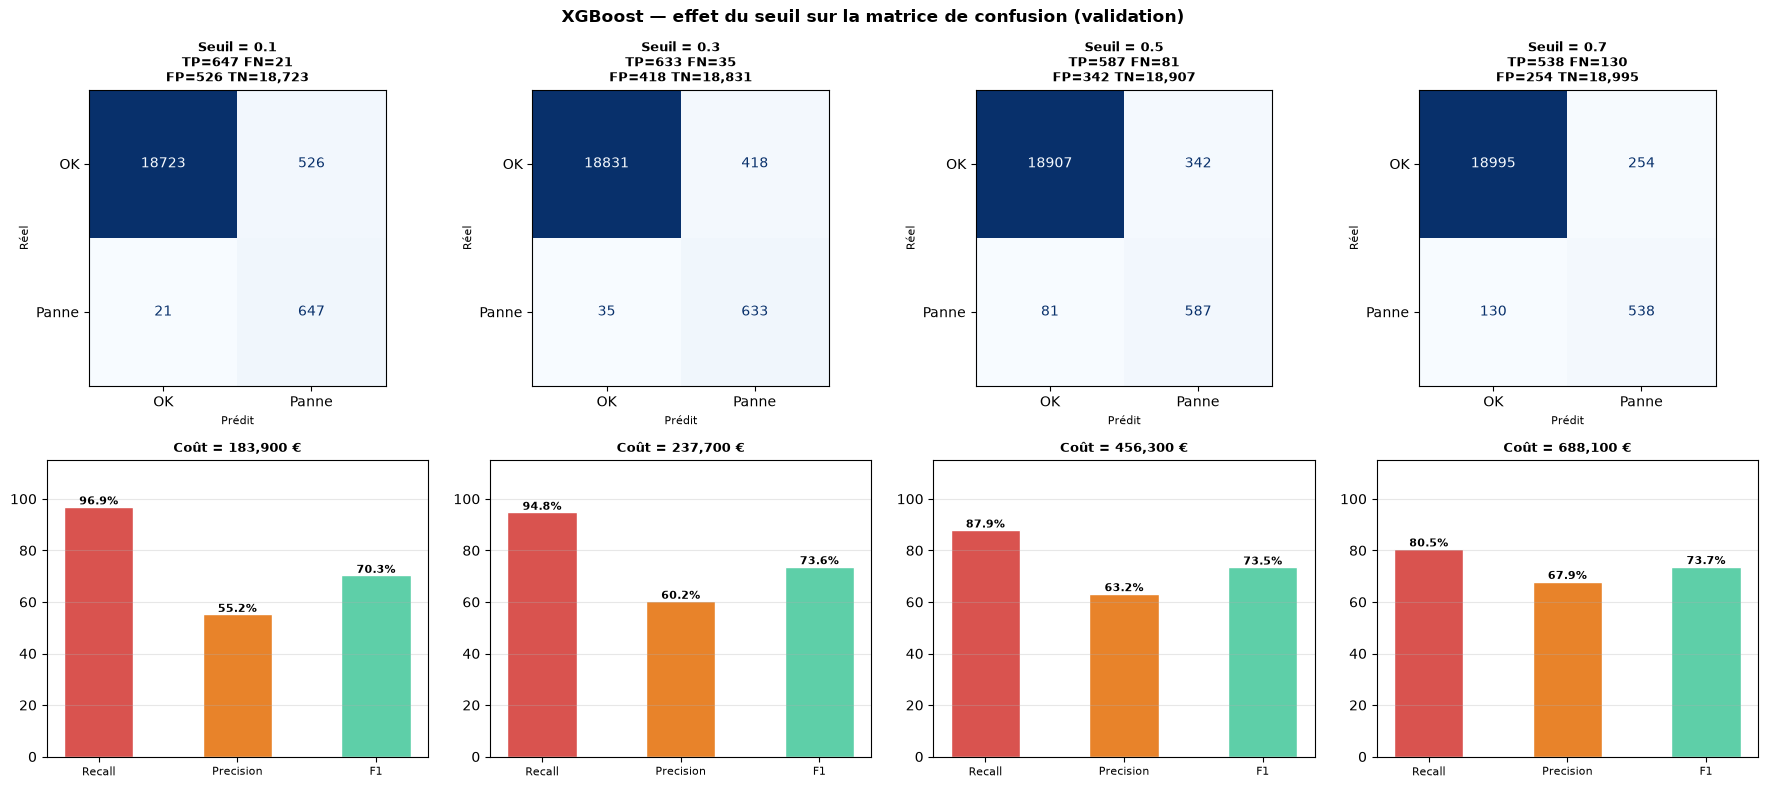

In [14]:
# Animation : matrice de confusion de XGBoost pour 4 seuils
model_name = "XGBoost"
y_proba_xgb = RESULTS[model_name]["y_proba"]

SEUILS = [0.1, 0.3, 0.5, 0.7]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, seuil in enumerate(SEUILS):
    y_pred_s = (y_proba_xgb >= seuil).astype(int)
    cm       = confusion_matrix(y_val, y_pred_s)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0
    cost_tot  = fn * COST_FN + fp * COST_FP

    # Ligne 1 : matrice
    disp = ConfusionMatrixDisplay(cm, display_labels=["OK", "Panne"])
    disp.plot(ax=axes[0, col], colorbar=False, cmap="Blues")
    axes[0, col].set_title(
        f"Seuil = {seuil}\nTP={tp:,} FN={fn:,}\nFP={fp:,} TN={tn:,}",
        fontsize=9, fontweight="bold", pad=6
    )
    axes[0, col].set_xlabel("Prédit", fontsize=8)
    axes[0, col].set_ylabel("Réel", fontsize=8)

    # Ligne 2 : barres métriques
    metrics_vals  = [recall*100, precision*100, f1*100]
    metrics_names = ["Recall", "Precision", "F1"]
    colors = ["#D9534F", "#E8832A", "#5ECFA8"]
    bars = axes[1, col].bar(metrics_names, metrics_vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, metrics_vals):
        axes[1, col].text(bar.get_x()+bar.get_width()/2, val+1,
                          f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")
    axes[1, col].set_ylim(0, 115)
    axes[1, col].set_title(f"Coût = {cost_tot:,} €", fontsize=9, fontweight="bold")
    axes[1, col].grid(alpha=0.3, axis="y")
    axes[1, col].tick_params(axis="x", labelsize=8)

plt.suptitle(f"XGBoost — effet du seuil sur la matrice de confusion (validation)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Courbe seuil → métriques pour les 3 modèles

On calcule Recall, Precision, F1 et le coût métier pour tous les seuils de 0 à 1.
Cette visualisation permet de **choisir le seuil optimal** selon la priorité.

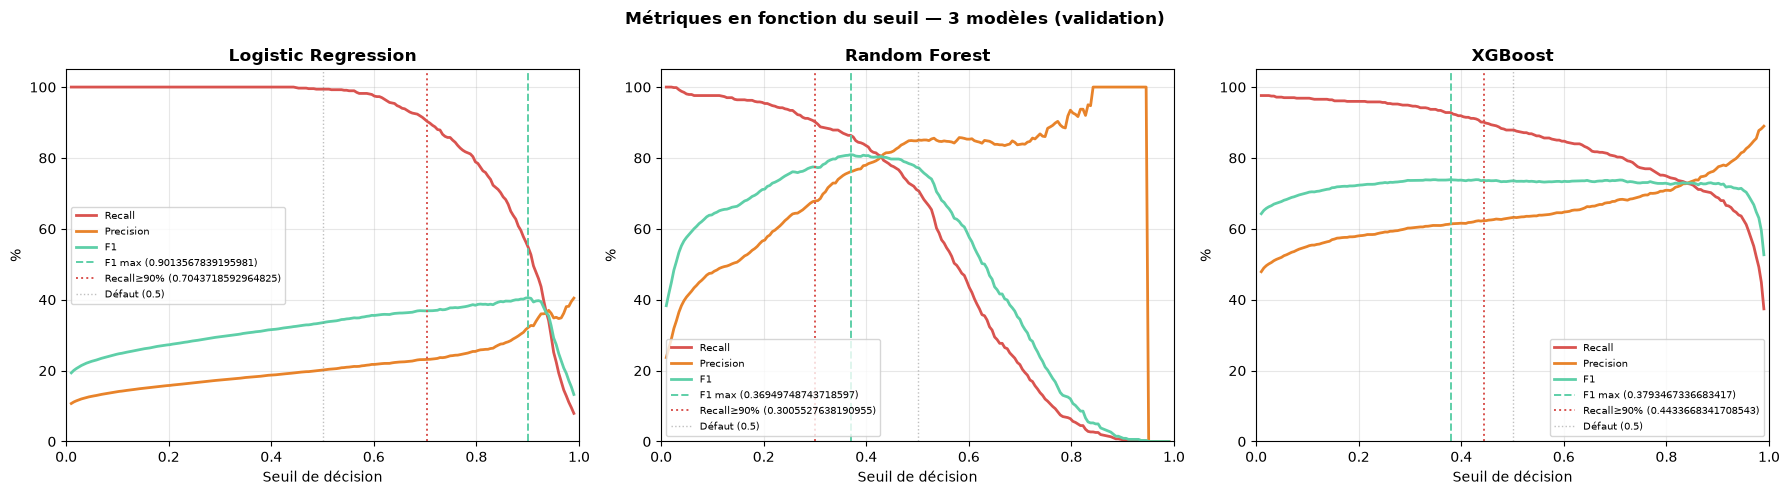

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
THRESHOLDS = np.linspace(0.01, 0.99, 200)

verdicts = {}

for ax, (name, res) in zip(axes, RESULTS.items()):
    y_proba = res["y_proba"]

    recalls, precisions, f1s, costs = [], [], [], []
    for t in THRESHOLDS:
        yp = (y_proba >= t).astype(int)
        tp = ((yp == 1) & (y_val == 1)).sum()
        fp = ((yp == 1) & (y_val == 0)).sum()
        fn = ((yp == 0) & (y_val == 1)).sum()
        r  = tp/(tp+fn) if (tp+fn) > 0 else 0
        p  = tp/(tp+fp) if (tp+fp) > 0 else 0
        f  = 2*p*r/(p+r) if (p+r) > 0 else 0
        recalls.append(r);     precisions.append(p)
        f1s.append(f);         costs.append(fn*COST_FN + fp*COST_FP)

    recalls = np.array(recalls); precisions = np.array(precisions)
    f1s = np.array(f1s); costs = np.array(costs)

    # Seuil F1 max
    idx_f1    = np.argmax(f1s)
    seuil_f1  = THRESHOLDS[idx_f1]

    # Seuil recall >= 90%
    idx_r90   = np.where(recalls >= 0.90)[0]
    seuil_r90 = THRESHOLDS[idx_r90[-1]] if len(idx_r90) > 0 else seuil_f1

    # Seuil coût min
    idx_cost  = np.argmin(costs)
    seuil_cost= THRESHOLDS[idx_cost]

    verdicts[name] = {
        "seuil_f1":   round(seuil_f1, 3),
        "seuil_r90":  round(seuil_r90, 3),
        "seuil_cost": round(seuil_cost, 3),
        "f1_max":     round(f1s[idx_f1], 4),
        "recall_at_f1":round(recalls[idx_f1]*100, 1),
        "cost_min":   int(costs[idx_cost]),
    }

    ax.plot(THRESHOLDS, recalls*100,     "-",  color="#D9534F", lw=2, label="Recall")
    ax.plot(THRESHOLDS, precisions*100,  "-",  color="#E8832A", lw=2, label="Precision")
    ax.plot(THRESHOLDS, f1s*100,         "-",  color="#5ECFA8", lw=2, label="F1")
    ax.axvline(seuil_f1,  color="#5ECFA8", linestyle="--", lw=1.4,
               label=f"F1 max ({seuil_f1})")
    ax.axvline(seuil_r90, color="#D9534F", linestyle=":",  lw=1.4,
               label=f"Recall≥90% ({seuil_r90})")
    ax.axvline(0.5,       color="gray",    linestyle=":",  lw=1, alpha=0.5,
               label="Défaut (0.5)")
    ax.set_xlabel("Seuil de décision"); ax.set_ylabel("%")
    ax.set_title(name, fontweight="bold")
    ax.legend(fontsize=7.5); ax.grid(alpha=0.3); ax.set_xlim(0, 1); ax.set_ylim(0, 105)

plt.suptitle("Métriques en fonction du seuil — 3 modèles (validation)", fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Verdict par modèle : quel seuil choisir ?

On dispose de 3 critères pour choisir le seuil, selon la priorité métier :

| Critère | Logique | Quand l'utiliser |
|---|---|---|
| **F1 max** | Équilibre Precision / Recall | Quand les deux coûts (FN et FP) sont proches |
| **Recall ≥ 90%** | Garantit de détecter 90% des pannes | Quand FN >> FP en coût (**notre cas**) |
| **Coût min** | Minimise le coût total FN×5000 + FP×150 | Quand les coûts sont chiffrés avec précision |

En maintenance industrielle : **Recall ≥ 90%** est le critère retenu par défaut.

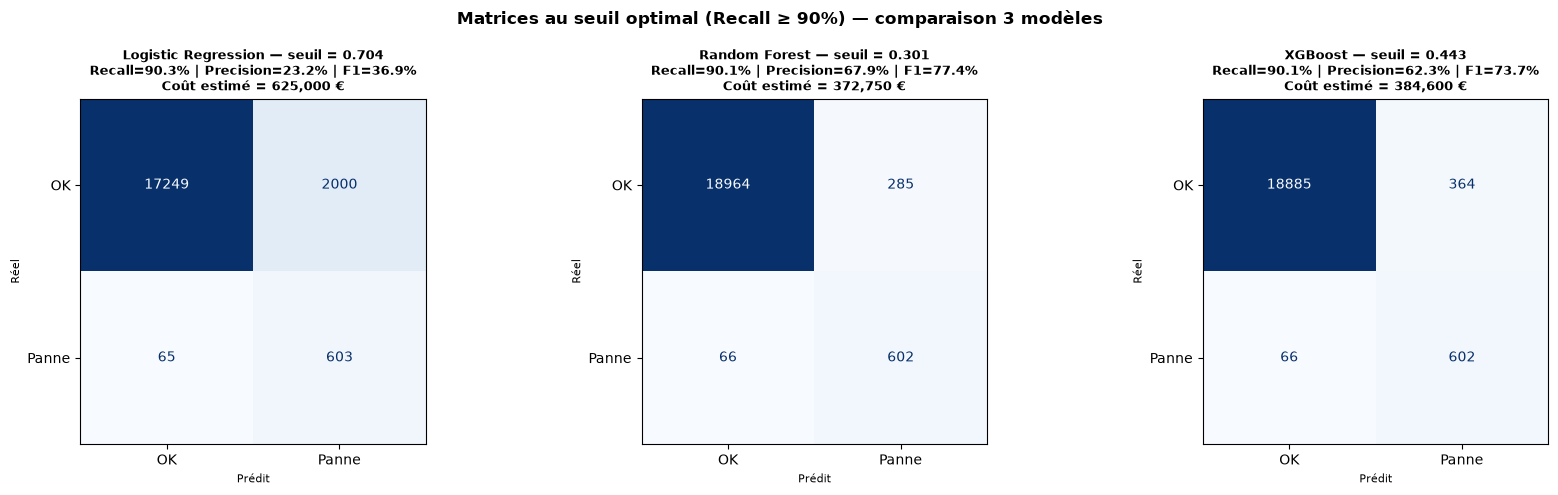

=== VERDICTS — Seuils recommandés ===
Modèle                   Seuil F1  Seuil R≥90%   Seuil coût min   Coût min (€)
------------------------------------------------------------------------------
Logistic Regression         0.901        0.704            0.537        403,450
Random Forest               0.369        0.301            0.113        182,450
XGBoost                     0.379        0.443            0.025        177,350


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, res) in zip(axes, RESULTS.items()):
    vd      = verdicts[name]
    y_proba = res["y_proba"]

    # Matrice au seuil Recall >= 90%
    seuil_retenu = vd["seuil_r90"]
    y_pred_ret   = (y_proba >= seuil_retenu).astype(int)
    cm_ret       = confusion_matrix(y_val, y_pred_ret)
    tn, fp, fn, tp = cm_ret.ravel()

    disp = ConfusionMatrixDisplay(cm_ret, display_labels=["OK", "Panne"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")

    cost_ret = fn * COST_FN + fp * COST_FP
    p_ret    = tp/(tp+fp)*100 if (tp+fp) > 0 else 0
    r_ret    = tp/(tp+fn)*100 if (tp+fn) > 0 else 0
    f1_ret   = 2*p_ret*r_ret/(p_ret+r_ret) if (p_ret+r_ret) > 0 else 0

    ax.set_title(
        f"{name} — seuil = {seuil_retenu}\n"
        f"Recall={r_ret:.1f}% | Precision={p_ret:.1f}% | F1={f1_ret:.1f}%\n"
        f"Coût estimé = {cost_ret:,} €",
        fontsize=9, fontweight="bold", pad=6
    )
    ax.set_xlabel("Prédit", fontsize=8); ax.set_ylabel("Réel", fontsize=8)

plt.suptitle("Matrices au seuil optimal (Recall ≥ 90%) — comparaison 3 modèles", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("=== VERDICTS — Seuils recommandés ===")
print(f"{'Modèle':<22} {'Seuil F1':>10} {'Seuil R≥90%':>12} {'Seuil coût min':>16} {'Coût min (€)':>14}")
print("-"*78)
for name, vd in verdicts.items():
    print(f"{name:<22} {vd['seuil_f1']:>10.3f} {vd['seuil_r90']:>12.3f} {vd['seuil_cost']:>16.3f} {vd['cost_min']:>14,}")

## 9. Comparaison seuil 0.5 vs seuil optimal — impact sur les FN

On quantifie le gain de chaque modèle quand on passe du seuil par défaut
au seuil optimal Recall ≥ 90%.

**La question clé** : combien de pannes supplémentaires détecte-t-on ?
Combien de fausses alarmes supplémentaires accepte-t-on en échange ?

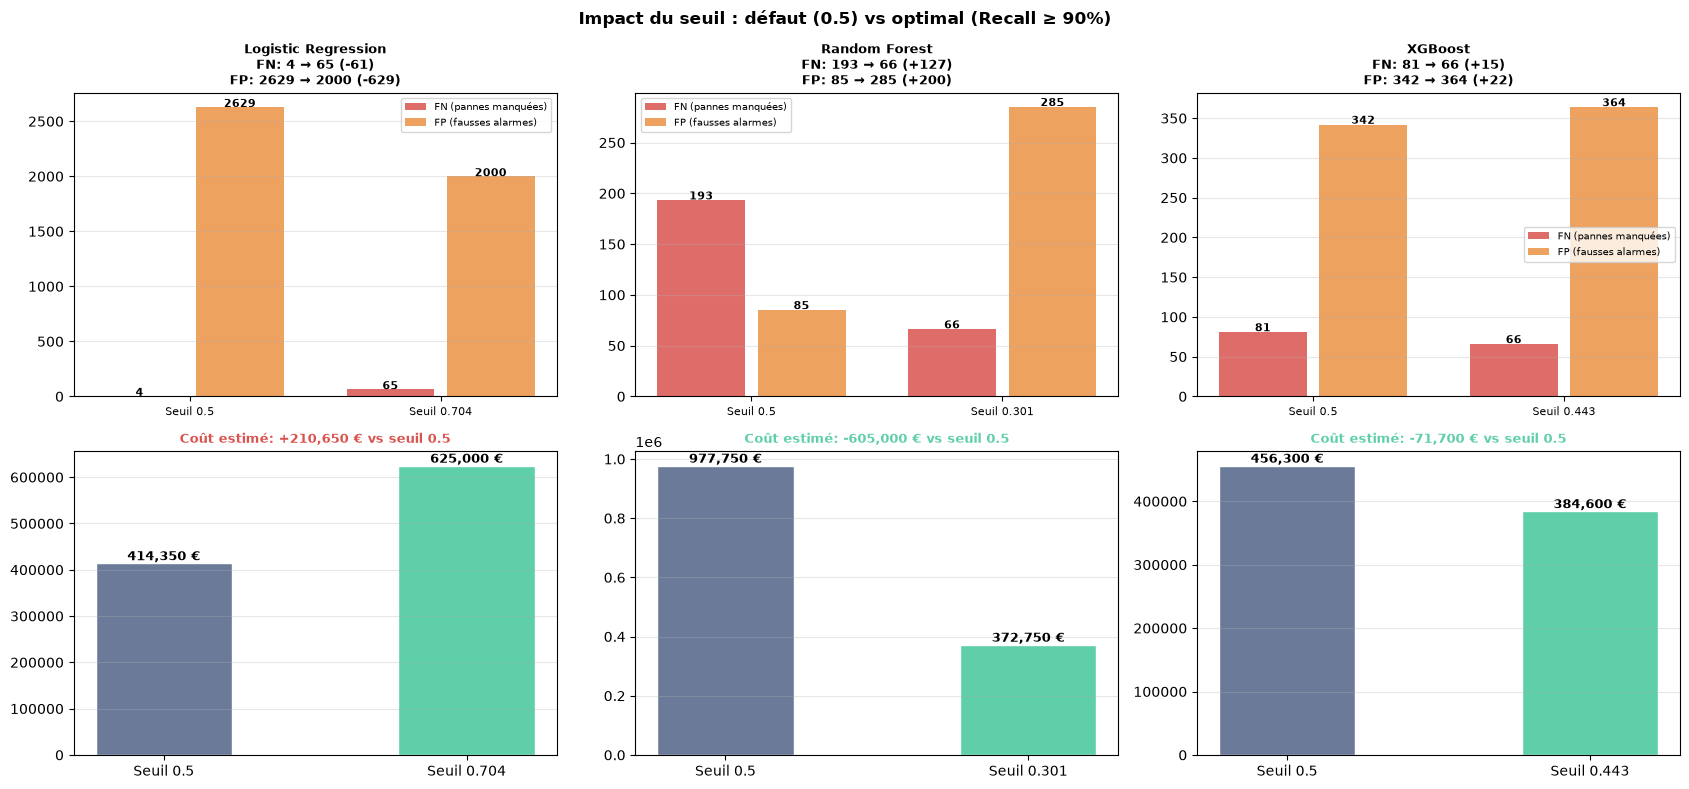

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
COLORS = {"Défaut (0.5)": "#6B7A99", "Seuil optimal": "#5ECFA8"}

for col, (name, res) in enumerate(RESULTS.items()):
    y_proba = res["y_proba"]
    seuil_opt = verdicts[name]["seuil_r90"]

    data = {}
    for label, seuil in [("Défaut (0.5)", 0.5), ("Seuil optimal", seuil_opt)]:
        yp = (y_proba >= seuil).astype(int)
        cm = confusion_matrix(y_val, yp)
        tn, fp, fn, tp = cm.ravel()
        data[label] = {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
                       "recall": tp/(tp+fn)*100 if (tp+fn) > 0 else 0,
                       "precision": tp/(tp+fp)*100 if (tp+fp) > 0 else 0,
                       "cost": fn*COST_FN + fp*COST_FP}

    # Ligne 1 : FN et FP comparés
    x = np.array([0, 1])
    fn_vals = [data["Défaut (0.5)"]["FN"], data["Seuil optimal"]["FN"]]
    fp_vals = [data["Défaut (0.5)"]["FP"], data["Seuil optimal"]["FP"]]

    axes[0, col].bar(x - 0.2, fn_vals, 0.35, color="#D9534F", label="FN (pannes manquées)", alpha=0.85)
    axes[0, col].bar(x + 0.2, fp_vals, 0.35, color="#E8832A", label="FP (fausses alarmes)", alpha=0.75)
    axes[0, col].set_xticks(x); axes[0, col].set_xticklabels(["Seuil 0.5", f"Seuil {seuil_opt}"], fontsize=8)
    axes[0, col].set_title(f"{name}\nFN: {fn_vals[0]} → {fn_vals[1]} ({fn_vals[0]-fn_vals[1]:+d})\nFP: {fp_vals[0]} → {fp_vals[1]} ({fp_vals[1]-fp_vals[0]:+d})",
                           fontsize=9, fontweight="bold")
    axes[0, col].legend(fontsize=7.5); axes[0, col].grid(alpha=0.3, axis="y")
    for b in axes[0, col].patches:
        axes[0, col].text(b.get_x()+b.get_width()/2, b.get_height()+1, str(int(b.get_height())),
                          ha="center", fontsize=8, fontweight="bold")

    # Ligne 2 : coût comparé
    costs_v = [data["Défaut (0.5)"]["cost"], data["Seuil optimal"]["cost"]]
    bar_c = axes[1, col].bar(["Seuil 0.5", f"Seuil {seuil_opt}"], costs_v,
                              color=["#6B7A99", "#5ECFA8"], edgecolor="white", width=0.45)
    for b, v in zip(bar_c, costs_v):
        axes[1, col].text(b.get_x()+b.get_width()/2, v + max(costs_v)*0.01,
                          f"{v:,} €", ha="center", fontsize=9, fontweight="bold")
    delta_cost = costs_v[1] - costs_v[0]
    axes[1, col].set_title(f"Coût estimé: {delta_cost:+,} € vs seuil 0.5", fontsize=9, fontweight="bold",
                           color="#5ECFA8" if delta_cost < 0 else "#D9534F")
    axes[1, col].grid(alpha=0.3, axis="y")

plt.suptitle("Impact du seuil : défaut (0.5) vs optimal (Recall ≥ 90%)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Conclusion — synthèse et recommandations

### Ce que la matrice de confusion révèle

| Dimension | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| Type d'erreur dominant | Beaucoup de FN et FP (faible discrimination) | Bon équilibre FN/FP | FN bas, FP modéré |
| Profil de risque | ❌ Inacceptable en production | ⚠️ Acceptable avec seuil ajusté | ✅ Meilleur candidat |
| Seuil recommandé (R≥90%) | *cf. résultats* | *cf. résultats* | *cf. résultats* |

### Règles retenues pour ce projet

1. **Métrique pivot** : PR-AUC — non biaisée par le déséquilibre (~3.6 % positifs)
2. **Coût asymétrique** : FN >> FP → optimiser le Recall en priorité
3. **Seuil de production** : ne pas utiliser 0.5 par défaut — l'ajuster pour atteindre Recall ≥ 90%
4. **Modèle retenu** : XGBoost — meilleure PR-AUC + gestion native du déséquilibre
5. **Prochaine étape (TP8 — B7)** : Optuna pour réduire l'overfitting et affiner le seuil optimal

### Interprétation de la matrice — résumé en 4 phrases

- **TP élevé** = maintenance planifiée à temps → zéro arrêt non planifié
- **FN bas** = peu de pannes manquées → coût de production maîtrisé
- **FP modéré** = quelques déplacements inutiles → coût acceptable si FN est bas
- **TN élevé** = la grande majorité des heures est correctement identifiée comme «tout va bien»

In [18]:
print("=" * 65)
print("RÉCAPITULATIF TP7bis — Matrices de confusion et coût métier")
print("=" * 65)
print(f"  COST_FN (panne manquée) : {COST_FN:,} €/erreur")
print(f"  COST_FP (fausse alarme) : {COST_FP:,} €/erreur")
print(f"  Ratio FN/FP             : {COST_FN/COST_FP:.0f}×")
print()
print(f"  {'Modèle':<22} {'PR-AUC':>8} {'Seuil opt':>10} {'Recall':>8} {'Coût (€)':>12}")
print("  " + "-"*65)
for name, res in RESULTS.items():
    vd     = verdicts[name]
    seuil  = vd["seuil_r90"]
    yp     = (res["y_proba"] >= seuil).astype(int)
    cm_v   = confusion_matrix(y_val, yp)
    tn, fp, fn, tp = cm_v.ravel()
    recall = tp/(tp+fn)*100
    cost   = fn*COST_FN + fp*COST_FP
    print(f"  {name:<22} {res['pr_auc']:>8.4f} {seuil:>10.3f} {recall:>7.1f}% {cost:>12,}")
print("=" * 65)

RÉCAPITULATIF TP7bis — Matrices de confusion et coût métier
  COST_FN (panne manquée) : 5,000 €/erreur
  COST_FP (fausse alarme) : 150 €/erreur
  Ratio FN/FP             : 33×

  Modèle                   PR-AUC  Seuil opt   Recall     Coût (€)
  -----------------------------------------------------------------
  Logistic Regression      0.3105      0.704    90.3%      625,000
  Random Forest            0.8170      0.301    90.1%      372,750
  XGBoost                  0.8174      0.443    90.1%      384,600
